# Problem presentation
### Identifying weather regimes using unsupervised learning
In this example we will use unsupervised learning to classify sea level pressure data into different "weather regimes". They allow to understand long term weather patterns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
import pandas as pd
import xarray as xr
import seaborn as sns
import cartopy.crs as ccrs

import sklearn

# STEP 1: Load and preprocess data
We use data from ERA5 which gives a grid over the entire world. We only focus on North Atlantic data.
The data is already prepared for you.


In [2]:
ds = xr.open_dataarray('../data/msl_data_northatlantic.nc')
longitude = ds.longitude
latitude = ds.latitude

In [3]:
X = ds.values
print(X.shape)

(3701, 31, 66)


### We can plot an example data point:

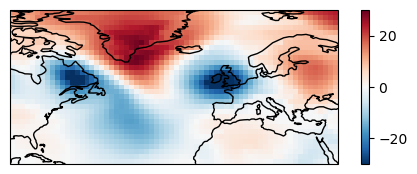

In [4]:
sample_to_plot = X[20]

fig, ax = plt.subplots(figsize=(6,2), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.coastlines()
im = ax.pcolormesh( longitude, latitude, sample_to_plot, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-30, vmax=30)
fig.colorbar(im, ax=ax)

## Note that we are using an **unsupervised** algorithm, there is no `y` data.

We need to flatten the data for this task. We will talk about reshaping data later.

In [5]:
X = X.reshape(-1, np.prod(X.shape[1:]))
print(X.shape)

(3701, 2046)


## **QUESTION 1**: Create train, validation and test datasets from `X`

In [6]:
X_train, X_valtest = sklearn.model_selection.train_test_split(X, train_size=0.7)
X_val, X_test = sklearn.model_selection.train_test_split(X_valtest, train_size=0.7)

# STEP 2: Define ML model and fit it to the data


## **QUESTION 2**: Define the KMeans model by creating the object `model` in the following cell.
There is one hyperparameter we can change here: `n_clusters`, it corresponds to the number of classes we want to split the data in. Choose what you feel appropriate.

In [7]:
n_clusters = 5
model = sklearn.cluster.KMeans(n_clusters=n_clusters)
model

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


## Step 2.2: Fit the model to the data
Once we have defined the model, we will fit the model to the data. The model will change some internal coefficients to determine the cluster centers.

## **QUESTION 3**: Fit the model to the **training data** in the following cell.

In [8]:
model.fit(X_train)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


## Plot the centroid of the clusters

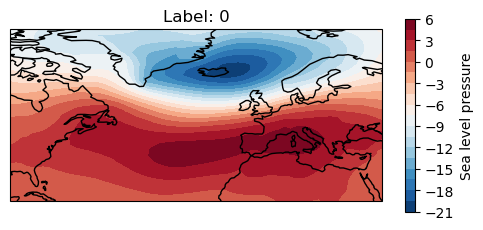

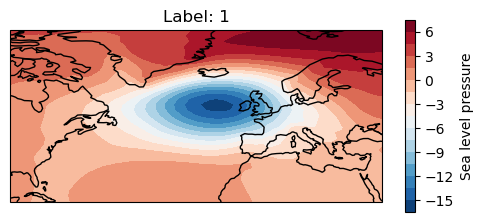

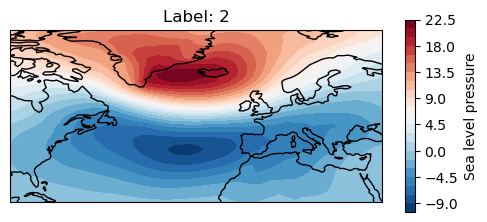

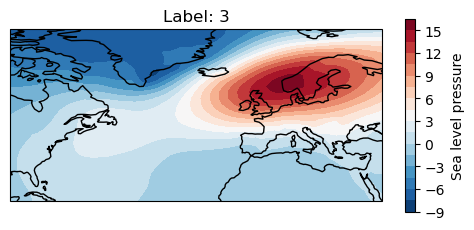

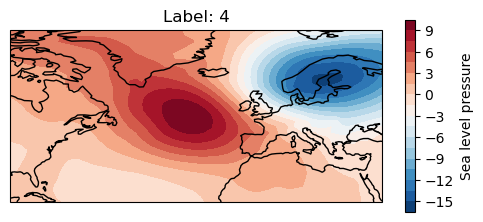

In [9]:
for k in range(n_clusters):
    fig, ax = plt.subplots(figsize=(6,2.5), subplot_kw=dict(projection=ccrs.PlateCarree()))
    pattern = model.cluster_centers_[k].reshape(len(ds.latitude), len(ds.longitude))
    contour = ax.contourf(ds.longitude, ds.latitude, pattern, cmap='RdBu_r', transform=ccrs.PlateCarree(), levels=20)
    ax.coastlines()
    ax.set_title(f"Label: {k:.0f}")
    fig.colorbar(contour, label='Sea level pressure')

# STEP 3: Make predictions and evaluate the model skill
Once the model is fitted to the data, we can use it to make predictions of clusters.

## Step 3.1: Predict clusters for `X`
We predict the clusters of `X` for the validation dataset.

## **QUESTION 4**: Use the **validation data** to predict clusters.

In [10]:
val_cluster = model.predict(X_val)

## Evaluate the results with `silhouette_score`.
The silouhette score is a way to quantify the skill of a clustering algorithm. For more details see the bonus slides!
You can compute it by using `sklearn.metrics.silhouette_score(X, clusters)`. It is between -1 and 1 and should be closer to 1.

## **QUESTION 5**: Compute the silhouette score of the validation data.

In [11]:
silhouette = sklearn.metrics.silhouette_score(X_val, val_cluster)
print(f"Silhouette score: {silhouette:.02f}")

Silhouette score: 0.10


## **QUESTION 6**: Change the number of clusters and compare results.
Is there an optimal number of clusters?